In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


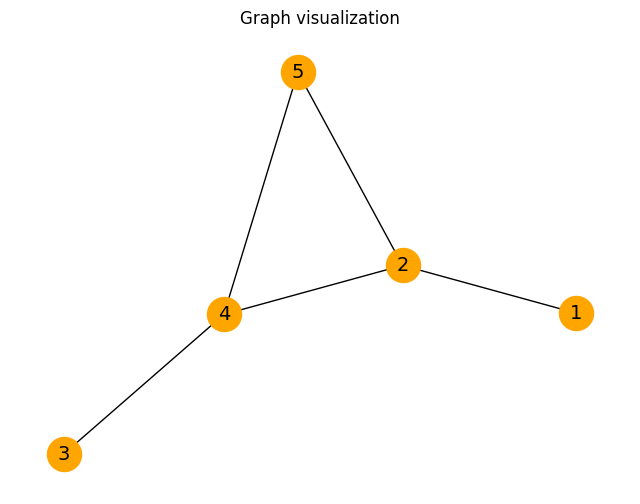

In [ ]:
# Create the graph with given edges
G = nx.Graph()
edges = [('1','2'), ('2','4'), ('2','5'), ('3','4'), ('4','5')]
G.add_edges_from(edges)

# Visualize the graph
plt.figure(figsize=(8, 6))
plt.axis('off')
pos = nx.spring_layout(G, seed=10)
nx.draw_networkx(G, pos=pos, node_size=600, node_color='orange', 
                 font_size=14, with_labels=True)
plt.title('Graph Structure')
plt.tight_layout()
plt.show()

# GNN Spectral Convolution
## Formula: H' = D⁻¹ * Â * X * W

### Graph & Problem Setup
- **Nodes**: 1, 2, 3, 4, 5 (5 nodes)
- **Edges**: [('1','2'),('2','4'),('2','5'),('3','4'),('4','5')]
- **Node Features**: Each node has 2 features
- **Weight Matrix W**: [[-1, 0.23], [0.5, 0]]

In [18]:
# Define node features and weight matrix
node_features = {
    '1': [1, 0],
    '2': [0, 2],
    '3': [2, 1],
    '4': [1, 3],
    '5': [3, 0]
}

X = np.array([node_features[str(i)] for i in range(1, 6)])
W = np.array([[-1, 0.23], [0.5, 0]])

print("Node Features (X):\n", X)
print("\nWeight Matrix (W):\n", W)

Node Features (X):
 [[1 0]
 [0 2]
 [2 1]
 [1 3]
 [3 0]]

Weight Matrix (W):
 [[-1.    0.23]
 [ 0.5   0.  ]]


In [24]:
# Step 1: Create Â = A + I (Adjacency matrix with self-loops)
A = np.array(nx.adjacency_matrix(G).todense())
I = np.eye(A.shape[0])
A_hat = A + I + I

print("Adjacency Matrix (Â = A + I):")
print(A_hat.astype(int))

Adjacency Matrix (Â = A + I):
[[2 1 0 0 0]
 [1 2 1 1 0]
 [0 1 2 1 1]
 [0 1 1 2 0]
 [0 0 1 0 2]]


In [26]:
# Step 2: Calculate degree matrix D and its inverse D⁻¹
degree = np.asarray(A_hat.sum(axis=1)).flatten()
D = np.diag(degree)
D_inv = np.linalg.inv(D)

print("Node Degrees:", degree.astype(int))
print("\nInverse Degree Matrix (D⁻¹):")
print(np.round(D_inv, 3))


Node Degrees: [3 5 5 4 3]

Inverse Degree Matrix (D⁻¹):
[[0.333 0.    0.    0.    0.   ]
 [0.    0.2   0.    0.    0.   ]
 [0.    0.    0.2   0.    0.   ]
 [0.    0.    0.    0.25  0.   ]
 [0.    0.    0.    0.    0.333]]


In [27]:
D

array([[3., 0., 0., 0., 0.],
       [0., 5., 0., 0., 0.],
       [0., 0., 5., 0., 0.],
       [0., 0., 0., 4., 0.],
       [0., 0., 0., 0., 3.]])

In [21]:
# Step 3: GNN Convolution - H' = D⁻¹ * Â * X * W
A_hat_X = np.dot(A_hat, X)
D_inv_A_hat_X = np.dot(D_inv, A_hat_X)
H_prime = np.dot(D_inv_A_hat_X, W)

print("After D⁻¹ * Â * X:\n", np.round(D_inv_A_hat_X, 3))
print("\nFinal Output H' = D⁻¹ * Â * X * W:\n", np.round(H_prime, 3))
print("\nOutput shape:", H_prime.shape)

After D⁻¹ * Â * X:
 [[0.5 1. ]
 [1.  1.5]
 [1.5 1.5]
 [1.  2. ]
 [2.5 0.5]]

Final Output H' = D⁻¹ * Â * X * W:
 [[ 0.     0.115]
 [-0.25   0.23 ]
 [-0.75   0.345]
 [ 0.     0.23 ]
 [-2.25   0.575]]

Output shape: (5, 2)


In [22]:
# Display results for each node
print("\nGNN Output for Each Node:")
print("=" * 50)
for i, node in enumerate(sorted(G.nodes())):
    print(f"Node {node}: {np.round(H_prime[i], 3)}")
print("=" * 50)


GNN Output for Each Node:
Node 1: [0.    0.115]
Node 2: [-0.25  0.23]
Node 3: [-0.75   0.345]
Node 4: [0.   0.23]
Node 5: [-2.25   0.575]


In [ ]:
# Check TensorFlow and Keras versions
import tensorflow as tf
import keras

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

array([[0.   , 0.115],
       [0.   , 0.23 ],
       [0.   , 0.345],
       [0.   , 0.23 ],
       [0.   , 0.575]])